<a href="https://colab.research.google.com/github/AditiSable18/CODTECH--Task-2/blob/main/Car_Market_Trends_Analysis_with_Car_Dekho_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Analysis Case Study - Car Dekho

## Project Description

This project performs an exploratory data analysis on the 'Car Dekho Data' dataset. The primary goal is to understand various aspects of the used car market, including pricing, depreciation, and factors influencing car sales. The analysis addresses several key questions related to vehicle characteristics, market trends, and depreciation insights. This includes:

*   **Data Overview**: Understanding the structure, types, and summary statistics of the data.
*   **Missing Values**: Checking for and handling any missing data points.
*   **Vehicle Demographics**: Identifying the range of manufacturing years, types of vehicles, and counts of different models.
*   **Pricing Analysis**: Determining the lowest and highest selling prices in the dataset.
*   **Fuel and Transmission Types**: Analyzing the distribution of fuel types and transmission types, including the presence and quantity of CNG and automatic transmission vehicles.
*   **Seller and Ownership Information**: Quantifying vehicles sold by individuals and those with single owners.
*   **Depreciation Analysis**: Calculating and identifying the most and least cost-depreciated vehicles, as well as brands that are less affected by depreciation.
*   **Factor Identification**: Exploring potential factors that influence cost depreciation through correlation analysis and observed trends.

This analysis aims to provide a comprehensive understanding of the dataset, highlighting important features and relationships that could be used for further modeling or business insights.

1. From which manufacturing year to which manufacturing year vehicles are present in this data?
2. What is the lowest price to which a vehicle is sold?
3. What is the highest price to which a vehicle is sold?
4. How many records are there in this data?
5. Are there any missing records in this data?
6. How many different vehicles present in this data?
7. Which is the most sold vehicle in this data?
8. Does this database include any CNG vehicle? If yes how many of them are there?
9. How many vehicles are for sell from individuals directly?
10. Does this database contain auto transmission vehicles? If yes how many of them are there?
11. How many single person owned vehicles are there in this database?
12. Which is the most and least cost depreciated vehicle in data?
13. Which brands of vehicles are less affected by cost depreciation?
14. Are there any factors which you feel affect the cost depreciation?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Importing data
data = pd.read_csv("/content/Car Dekho Data.csv")
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
#To check statistical features of the data
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
#Checking whether the non numeric variables are categorical in nature
print(data.Car_Name.value_counts())

Car_Name
city                  26
corolla altis         16
verna                 14
fortuner              11
brio                  10
                      ..
Honda Activa 125       1
Hero Hunk              1
Hero  Ignitor Disc     1
Hero  CBZ Xtreme       1
Bajaj  ct 100          1
Name: count, Length: 98, dtype: int64


There are 98 different vehicles in the data. It contains bikes and mopets too. Variable is categorical.

In [ ]:
print(data.Fuel_Type.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


([<matplotlib.patches.Wedge at 0x7a0121d18c20>,
 [Text(-0.8776154781950629, 0.6631674542922408, 'Petrol'),
  Text(0.8635822151017053, -0.6813411463870594, 'Diesel'),
  Text(1.0997603530979516, -0.022960090458647577, 'CNG')])

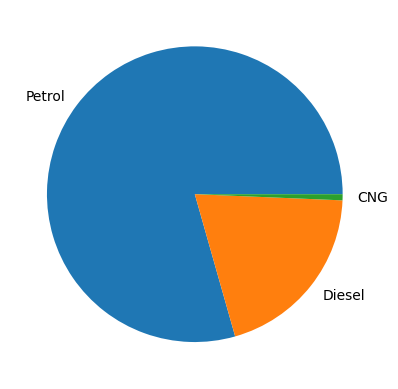

In [ ]:
plt.pie(data.Fuel_Type.value_counts(), labels=["Petrol", "Diesel", "CNG"], shadow = plt.show())

<Axes: xlabel='Fuel_Type'>

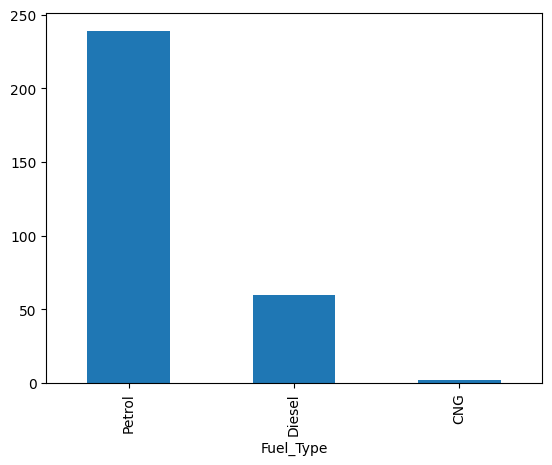

In [ ]:
data.Fuel_Type.value_counts().plot.bar()

The data contains mostly petrol vehicles. This variable is skewed. Variable is categorical.

In [ ]:
print("Number of Different Vehicles")
print(f"Unique vehicles: {data['Car_Name'].nunique()}")


Number of Different Vehicles
Unique vehicles: 98


In [ ]:
print("Vehicles sold by Individuals")
print(f"Individual sellers: {(data['Seller_Type'] == 'Individual').sum()}")

Vehicles sold by Individuals
Individual sellers: 106


In [ ]:
print("Automatic Transmission Vehicles")
auto_count = (data['Transmission'] == 'Automatic').sum()
print(f"Automatic vehicles: {auto_count}")

Automatic Transmission Vehicles
Automatic vehicles: 40


In [ ]:
print("Single Person Owned Vehicles (Owner == 0)")
print(f"First owner vehicles: {(data['Owner'] == 0).sum()}")

Single Person Owned Vehicles (Owner == 0)
First owner vehicles: 290


In [ ]:
print("\n12. Most and Least Cost Depreciated Vehicles")

data['Depreciation'] = data['Present_Price'] - data['Selling_Price']

most = data.loc[data['Depreciation'].idxmax()]
least = data.loc[data['Depreciation'].idxmin()]

print("\nMOST depreciated:")
print(f"  Car            : {most['Car_Name']}")
print(f"  Year           : {most['Year']}")
print(f"  Present Price  : {most['Present_Price']}")
print(f"  Selling Price  : {most['Selling_Price']}")
print(f"  Depreciation   : {most['Depreciation']:.2f} lakhs")

print("\nLEAST depreciated:")
print(f"  Car            : {least['Car_Name']}")
print(f"  Year           : {least['Year']}")
print(f"  Present Price  : {least['Present_Price']}")
print(f"  Selling Price  : {least['Selling_Price']}")
print(f"  Depreciation   : {least['Depreciation']:.2f} lakhs")



12. Most and Least Cost Depreciated Vehicles

MOST depreciated:
  Car            : land cruiser
  Year           : 2010
  Present Price  : 92.6
  Selling Price  : 35.0
  Depreciation   : 57.60 lakhs

LEAST depreciated:
  Car            : Honda Activa 4G
  Year           : 2017
  Present Price  : 0.51
  Selling Price  : 0.48
  Depreciation   : 0.03 lakhs


In [ ]:
print("Brands less affected by Cost Depreciation")

data['Brand'] = data['Car_Name'].str.split().str[0]

# Absolute depreciation
avg_abs = data.groupby('Brand')['Depreciation'].mean().sort_values()
print("\nLowest Average Absolute Depreciation:")
print(avg_abs.head(10))

# Percentage depreciation
data['Dep_Pct'] = (data['Depreciation'] / data['Present_Price']) * 100
avg_pct = data.groupby('Brand')['Dep_Pct'].mean().sort_values()
print("\nLowest Average % Depreciation:")
print(avg_pct.head(10))

print("\n→ Brands least affected (low % depreciation):", list(avg_pct.head(6).index))

Brands less affected by Cost Depreciation

Lowest Average Absolute Depreciation:
Brand
UM          0.120000
Activa      0.183333
TVS         0.242750
Mahindra    0.250000
Yamaha      0.258750
Hero        0.265200
Honda       0.318824
Suzuki      0.330000
Bajaj       0.334400
Royal       0.423529
Name: Depreciation, dtype: float64

Lowest Average % Depreciation:
Brand
vitara       5.900305
UM           6.593407
creta       13.235294
grand       13.267544
ignis       14.185639
Mahindra    17.857143
elantra     21.568627
brio        21.746245
ciaz        22.487716
s           24.506388
Name: Dep_Pct, dtype: float64

→ Brands least affected (low % depreciation): ['vitara', 'UM', 'creta', 'grand', 'ignis', 'Mahindra']


In [ ]:
print("\n14. Factors affecting Cost Depreciation")
print("""
Key factors observed:
1. Age (Year) – older cars depreciate more
2. Kilometers Driven – higher km → lower residual value
3. Fuel Type
4. Transmission type
5. Number of previous owners
6. Brand / Original Present Price
7. Seller Type
""")

print("\nCorrelation with Depreciation:")
print(data[['Year', 'Kms_Driven', 'Present_Price', 'Owner', 'Depreciation']].corr()['Depreciation'].sort_values(ascending=False))


14. Factors affecting Cost Depreciation

Key factors observed:
1. Age (Year) – older cars depreciate more
2. Kilometers Driven – higher km → lower residual value
3. Fuel Type
4. Transmission type
5. Number of previous owners
6. Brand / Original Present Price
7. Seller Type


Correlation with Depreciation:
Depreciation     1.000000
Present_Price    0.864902
Kms_Driven       0.333832
Owner            0.107415
Year            -0.333746
Name: Depreciation, dtype: float64
